In [288]:
import pandas as pd
import matplotlib.pyplot as plt

In [289]:
df=pd.read_csv("adult_census_income.csv")

In [290]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [291]:
df.tail()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
465,32,State-gov,479179,11th,7,Never-married,Protective-serv,Own-child,White,Male,0,0,40,United-States,<=50K
466,47,Federal-gov,471990,Masters,14,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,40,United-States,>50K
467,50,Private,44728,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K
468,32,Private,33117,Assoc-voc,11,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,United-States,<=50K
469,19,Private,264876,HS-grad,9,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,40,United-States,<=50K


In [292]:
df.shape

(470, 15)

In [293]:
df.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [294]:
df.duplicated

<bound method DataFrame.duplicated of      age    workclass  fnlwgt     education  educational-num  \
0     25      Private  226802          11th                7   
1     38      Private   89814       HS-grad                9   
2     28    Local-gov  336951    Assoc-acdm               12   
3     44      Private  160323  Some-college               10   
4     18            ?  103497  Some-college               10   
..   ...          ...     ...           ...              ...   
465   32    State-gov  479179          11th                7   
466   47  Federal-gov  471990       Masters               14   
467   50      Private   44728       HS-grad                9   
468   32      Private   33117     Assoc-voc               11   
469   19      Private  264876       HS-grad                9   

         marital-status         occupation relationship   race  gender  \
0         Never-married  Machine-op-inspct    Own-child  Black    Male   
1    Married-civ-spouse    Farming-fishing   

In [295]:
df.drop_duplicates(inplace=True)

In [296]:
df.dtypes

age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object

In [297]:
column=["workclass","education",
        "marital-status","occupation",
        "relationship","race","gender",
        "native-country","income",
        ]

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for i in column:
    df[i]=le.fit_transform(df[i])

In [298]:
df.dtypes

age                int64
workclass          int64
fnlwgt             int64
education          int64
educational-num    int64
marital-status     int64
occupation         int64
relationship       int64
race               int64
gender             int64
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country     int64
income             int64
dtype: object

In [299]:
x=df.drop(columns="income")
y=df["income"]

In [300]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.30,random_state=42)

In [301]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [302]:
scaler.fit(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)

In [303]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,accuracy_score

knn=KNeighborsClassifier(n_neighbors=5)
svm=SVC()
nb=GaussianNB()

lst=[knn,svm,nb]

In [304]:
for i in lst:
    print("model selection_____________",i)
    print(i.fit(x_train,y_train))
    y_pred=i.predict(x_test)

    print("confusion_matrix_____________",i)
    print(confusion_matrix(y_test,y_pred))

    print("accuracy_score___________",i)
    print(accuracy_score(y_test,y_pred))

model selection_____________ KNeighborsClassifier()
KNeighborsClassifier()
confusion_matrix_____________ KNeighborsClassifier()
[[96 15]
 [11 19]]
accuracy_score___________ KNeighborsClassifier()
0.8156028368794326
model selection_____________ SVC()
SVC()
confusion_matrix_____________ SVC()
[[105   6]
 [ 21   9]]
accuracy_score___________ SVC()
0.8085106382978723
model selection_____________ GaussianNB()
GaussianNB()
confusion_matrix_____________ GaussianNB()
[[104   7]
 [ 17  13]]
accuracy_score___________ GaussianNB()
0.8297872340425532


In [305]:
from sklearn.metrics import classification_report
cr=classification_report(y_pred,y_test)
print(cr)

              precision    recall  f1-score   support

           0       0.94      0.86      0.90       121
           1       0.43      0.65      0.52        20

    accuracy                           0.83       141
   macro avg       0.69      0.75      0.71       141
weighted avg       0.87      0.83      0.84       141



<BarContainer object of 3 artists>

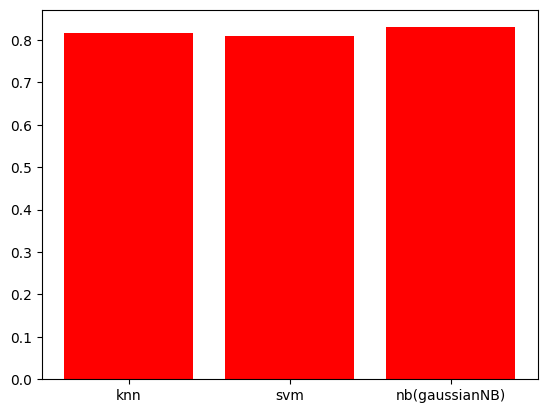

In [311]:
models=["knn","svm","nb(gaussianNB)"]
accuracy=[0.8156028368794326,0.8085106382978723,0.8297872340425532]
plt.bar(models,accuracy,color="r")